#  dapo的clip-higher 选择性地提升高熵 token 的熵，在不损害语言流畅性的前提下增强推理探索。

在大语言模型（LLM）的强化学习（RL）训练中，模型经常面临一个致命问题：<font color='red'>熵坍缩（Entropy Collapse）</font>。
- 随着训练的推进，**模型为了追求高奖励，会迅速收敛到少数几个高概率的 token 上**，导致采样空间崩塌，**推理路径变得单一，丧失探索新解法的能力。**

DAPO 算法提出的 Clip-Higher（高限裁剪） 机制，正是为了解决这一痛点。它通过一种极其精妙的“非对称裁剪”设计，在不破坏语言流畅性的前提下，**精准提升了高熵 token 的探索空间。**以下是其核心机制的详细拆解：

##  核心原理：解耦上下界的非对称裁剪
传统的 PPO 算法采用对称的裁剪区间（如 [1−ε,1+ε] ），同等限制新旧策略概率比的变化。这虽然保证了稳定性，但<font color='red'>也无意中限制了模型探索“低概率但可能正确”的新 token</font>

### DAPO 打破了这种对称性，将裁剪范围解耦为两个独立的边界：
- 低裁剪（ εlow）：通常设置得较小。**用于限制高概率 token 的概率下降，防止其概率骤减，从而保持模型输出的稳定性和语言流畅性。**
- 高裁剪（εhigh）：通常设置得较大。<font color='red'>用于放宽对低概率 token 的提升限制，允许它们有更大的更新空间，从而促进推理路径的结构性探索</font>。

##  <font color='red'>为什么能“选择性地提升高熵 token”？</font>
研究发现，大模型的推理过程融合了先验知识和可读性要求，导致思维链中绝大多数 token 是低熵的（为了保持语言流畅），只有少数关键决策点（即“岔路口”）是高熵的。
<font color='blue'>Clip-Higher 机制之所以能精准作用于高熵 token，是因为：</font>
- 被裁剪的 token 的最大输出概率通常小于 0.2。这意味着 Clip-Higher 主要影响的是那些低概率 token。
- 当优势信号为正（ A>0 ，即奖励为正）时，较大的$ε_{high}$允许这些低概率 token 的概率大幅提升。
- **在推理树中，这些低概率但正确的 token 往往对应着“稀有但正确”的推理分支**。放开它们的更新限制，等于帮助模型保留了这些关键的探索路径，从而提升了整体推理的局部熵。

##  为什么不损害语言流畅性？
**语言流畅性依赖于模型对常见词汇和语法结构的稳定输出（即低熵多数派 token）。**
- Clip-Higher 机制只放大了概率上限（ $ε_{high}$），并没有改变概率下限（ $ε_{low}$）。
- **因此，那些模型已经非常确定的高概率 token，依然受到严格的保守约束，其生成逻辑不会被破坏。**
- <font color='blue'>相比于</font>粗暴地给整个模型加“熵奖励（Entropy Bonus）”（**这会增加低熵多数词元的熵，导致模型胡言乱语**），
- Clip-Higher 是一种“微调”。**它只针对那 20% 真正影响推理方向的“高熵少数派”发力，在提升探索能力的同时，完美保留了基础模型的语言连贯性**。

## 总结来说，
- DAPO 的 Clip-Higher 就像是给模型的推理思维装了一个“智能变速箱”：
  - <font color='blue'>在常规的语言表达上（低熵 token），它保持平稳输出</font>
  - <font color='red'>而在遇到关键的逻辑分叉口（高熵 token）时，它允许模型大胆尝试那些原本概率较低、但可能通向正确解法的新路径。</font>

# 演示一下 Clip-Higher 在采样时到底怎么改变 token 概率分布

**题目：“小明有 5 个苹果，吃了 2 个，又买了 3 个，现在他有多少个苹果？”**

假设模型当前已经生成了：“小明有 5 个苹果，吃了 2 个，现在剩下 3 个，<font color='red'>接下来</font>”
在这个关键的逻辑分叉口（高熵 token），模型面临三种可能的下一步走向：
- Token A（常规废话）：“然后” （基础模型认为最顺口，概率极高）
- Token B（错误推理）：“减去 3” （错误的逻辑分支）
- Token C（正确但罕见的推理）：“再加上 3” （**正确的逻辑，但模型之前很少这么表达，概率较低**）

## 传统 PPO 的困境（对称裁剪）
假设此时环境给出了正向奖励（ A>0 ，即“**接下来**”这个词导向了最终正确的答案）。
在传统 PPO 算法中，假设裁剪范围是 ε=0.2 （即概率比被限制在 [0.8,1.2] 之间）。
- Token A（“然后”）：基础概率是 0.80。上限被限制为 0.80×1.2=0.96 。
- Token C（“再加上 3”）：基础概率是 **0.05**。上限被限制为 0.05×1.2=0.06 。
** 结果：** 
- <font color='red'>虽然 Token C 是正确的，但它的概率上限依然极低（只有 0.06）。模型在采样时，大概率还是会选择 Token A，导致推理路径变得平庸，或者陷入死胡同。</font>

## DAPO Clip-Higher 的破局（非对称裁剪）
DAPO 打破了这种对称性。假设它设定 $ε_{low}=0.2 $（保守），而 $ε_{high}$=<font color='red'>2.0</font> （激进）。

当正向奖励（ A>0 ）传来时，Clip-Higher 开始发力：
- 对 Token A（“然后”）的限制：
  - 由于它是高概率 token，受$ε_{low}$约束。它的概率上限依然是 0.80×1.2=0.96 。
(<font color='red'>作用：保证了语言依然通顺，模型不会突然胡言乱语</font>)
- **对 Token C（“再加上 3”）的放飞**：
  - 由于它是低概率 token，受 $ε_{high}$约束。它的概率上限被放宽到了 0.05×(1+2.0)=0.15 。
(<font color='red'>作用：概率上限从 0.06 暴涨到了 0.15！</font>)

## 采样时的实际变化（归一化后）
在 Softmax 归一化之后，整个词表的概率分布会发生显著的结构性变化：

| Token 选项 | 基础模型概率 | 传统 PPO 概率上限 | DAPO Clip-Higher 概率上限 | 变化效果 |
| :--- | :--- | :--- | :--- | :--- |
| “然后” (Token A) | 0.80 | 0.96 | 0.96 | 语言流畅性被完美保留 |
| “减去 3” (Token B) | 0.15 | 0.18 | 0.18 | 错误路径被压制 |
| “再加上 3” (Token C) | 0.05 | 0.06 | 0.15 | <font color='red'>正确但罕见的推理路径被大幅放大</font> |

## 总结
通过这个例子你可以清晰地看到：
- Clip-Higher 就像是在推理的“岔路口”安装了一个放大镜。它没有改变模型对日常词汇（如“然后”）的认知，
- <font color='red'>但精准地将那些“原本概率只有 5%，但却是通向正确答案的唯一路径”的 token，其采样概率放大了两三倍。</font>

这就完美解释了论文中的那句话：**在不损害语言流畅性的前提下，极大地增强了模型对复杂推理路径的探索能力。**


# DAPO 的 Clip-Higher：从"对称枷锁"到"非对称松绑"

这句话描述的是 DAPO 论文中最核心的技术创新之一。
- <font color='red'>要真正理解它，需要先从传统 PPO/GRPO 的裁剪机制说起，再看 DAPO 如何"对症下药"。</font>

## 背景：PPO/GRPO 的<font color='red'>"对称裁剪"是什么？</font>
在强化学习中，PPO（Proximal Policy Optimization）**引入了一个裁剪（clip）机制，用来限制策略更新的幅度，防止策略"暴走"**。
  - 具体来说，它用一个重要性采样比率 $r_t(θ) $ <font color='red'>来衡量当前策略相对于旧策略的变化：</font>
  $r_t(\theta) = \frac{\pi_\theta(o_t \|q,o_{<t})}{\pi_\theta(o_{old} \|q,o_{<t})}$
  - 然后，PPO 的目标函数是:
    $\min \left( r_t(\theta) \hat{A}_t, \; \text{clip}\left(r_t(\theta), \; 1 - \varepsilon, \; 1 + \varepsilon\right) \hat{A}_t \right)$
  - 这里的 clip(r,1−ε,1+ε)  意思是：
    - 如果 r>1+ε ，就把它"砍"到 1+ε 
    - 如果 r<1−ε ，就把它"砍"到 1−ε 
    - 传统设置中，$ε_{low}=ε_{high}=0.2$ （对称裁剪）
    
## 问题：对称裁剪为什么会导致"熵崩溃"？
DAPO 论文揭示了一个关键洞察 **：对称裁剪对"高概率 token"和"低概率 token"的约束是不对称的。**
- 论文举了一个非常直观的例子：
    假设 ε=0.2 ，考虑两个 token：
  - Token A：旧策略概率 $π_{old}=0.01$ （低概率，模型不太确定）
  - Token B：旧策略概率 $π_{old}=0.9 $（高概率，模型很确定）
- 那么更新后的最大可能概率分别是：
  - Token A：0.01×(1+0.2)=0.012 （只能提升 20%）
  - Token B：0.9×(1+0.2)=1.08 （理论上可以提升到接近 1.0）
  
### <font color='red'>这意味着什么？</font>

| Token 类型          | 旧概率  | 最大可提升 | 结果                   |
| ----------------- | ---- | ----- | -------------------- |
| **探索 token**（低概率） | 0.01 | 0.012 | **极难被提升，几乎被"锁死"在低概率区**   |
| **利用 token**（高概率） | 0.9  | 1.08  | <font color='red'>几乎不受限，可以轻松被强化到接近 1.0</font> |

**论文还发现，被裁剪 token 的最大概率实际上被限制在约 0.2 以下。**
<font color='red'>这就是熵崩溃的根源：</font> 
  - 低概率的"探索 token"被上界裁剪死死限制，
  - 而高概率的"利用 token"却可以自由增长。**模型越来越确定，越来越不愿意尝试新东西，熵（不确定性）迅速下降到接近 0。**
- 直观类比：想象你在一个迷宫中，对称裁剪就像在说"你可以走任何路，但每条新路的门缝只能开 20%，<font color='red'>而老路的门可以完全敞开"。结果你只会反复走老路。</font>

## Clip-Higher 的解决方案：非对称裁剪
DAPO 的核心创新是<font color='red'>将裁剪范围解耦</font>：
  $clip(r_t(\theta),1-\epsilon_{low},1+\epsilon_{high})$

其中：
  - $ε_{low}=0.2 $（保持较小）：防止高概率 token 被过度抑制
  - $ε_{high}=0.28$ （设得更大）：<font color='red'>给低概率 token 更大的提升空间</font>
  
### 为什么这样设计？

| 参数                             | 作用     | 效果                          |
| ------------------------------ | ------ | --------------------------- |
| ε_{low} 较小  | 下界裁剪宽松 | 高概率 token 不会被过度打压，语言流畅性得以保持 |
| ε_{low} 较大 | 上界裁剪宽松 | 低概率 token 有更大的概率提升空间，探索能力增强 |

## "选择性地提升高熵 token"是什么意思？
这里需要理解一个关键对应关系：
  **高熵 token ≈ 低概率 token**
- 在语言模型中，熵衡量的是概率分布的"平坦程度"：
  - 高熵 token：<font color='red'>概率分布比较平坦，多个候选 token 的概率相近，模型"犹豫不决"</font>
  - 低熵 token：**概率分布很尖锐，某个 token 概率接近 1.0，模型"非常确定"**
- Clip-Higher 的"选择性"体现在：
  - 低概率 token（高熵）：由于 $ε_{high}$更大，$r_t(θ)$  可以突破 1.2  的限制，达到 1.28  甚至更高。这意味着这些 token 的概率提升空间从 20% 扩展到了 28% 以上。**模型可以更积极地把概率"拨给"这些不确定的 token。**
  - 高概率 token（低熵）：由于 $ ε_{low}$ 保持较小，$r_t(θ)$  的下限仍然是 0.8 。这些 token 不会被过度惩罚，其概率不会断崖式下跌。
  
换句话说，Clip-Higher 不是"均匀撒糖"，而是"精准施肥"——专门给那些被对称裁剪压制的"边缘 token"松绑。

## <font color='red'>"不损害语言流畅性"是如何做到的？</font>
**这是 Clip-Higher 设计的精妙之处，关键在于下界裁剪的保守性：**

###  <font color='blue'>高概率 token 是语言流畅性的基石</font>
在正常的语言生成中，语法正确、语义连贯的 token（如 "the", "is", "therefore"）通常具有高概率。
 - **如果下界裁剪太激进（$ε_{low}$太大），会强制压低这些 token 的概率，导致：**
   - 语法结构被破坏
   - 生成内容变得不连贯
   - 出现"胡言乱语"（gibberish）
   
###  Clip-Higher 保持 $ε_low$较小
**这意味着高概率 token 仍然受到保护，不会被强制大幅下调。**
- 模型在"主流"生成路径上的稳定性得以保持。

###  相关研究佐证
- Liu 等人的研究进一步指出，保守的裁剪界限会阻碍连接性 token（如 "therefore", "but"）的概率提升——而这些 token 恰恰是推理方向转换的关键。 
- Clip-Higher 通过放宽上界，反而帮助了这些关键连接词的概率提升，促进了推理的多样性。

## 实验效果：熵崩溃 vs. <font color='red'>熵维持</font>
DAPO 论文中的 Figure 2 非常直观地展示了 Clip-Higher 的效果：

| 指标           | 不使用 Clip-Higher | 使用 Clip-Higher    |
| ------------ | --------------- | ----------------- |
| **生成熵**      | 快速崩溃至接近 0       | 稳定在 0.4 左右，甚至缓慢上升 |
| **AIME 准确率** | 约 25%，且波动大      | 约 40%，持续提升        |
| **响应多样性**    | 同组样本几乎完全相同      | 同组样本保持显著差异        |
- 论文中的 Figure 3a 还显示，被裁剪 token 的最大概率被限制在约 0.2 以下，这直接支持了"上界裁剪限制低概率 token"的分析

## 一句话总结
- Clip-Higher 的本质是"非对称松绑"：
  - 它放宽了对低概率 token（高熵/探索性 token）的概率提升限制，
  - 同时保持对高概率 token（低熵/确定性 token）的保护，从而在维持语言流畅性的前提下，为模型打开了更广阔的推理探索空间，有效避免了熵崩溃。

# 高概率 token 并不会因此获得更大的有效提升空间

## 物理天花板：概率不能超过 1.0
高概率 token（如旧概率 $π_{old}=0.9$ ）的提升空间受限于概率的物理上限 1.0：

| ε_high | 理论最大概率                   | 实际可达空间                   |
| --------------------------- | ------------------------ | ------------------------ |
| 0.2                         | 0.9 × 1.2 = 1.08  | 最多到 1.0，实际提升空间 **0.1**   |
| 0.28                        | 0.9 × 1.28 = 1.15 | 最多到 1.0，实际提升空间仍是 **0.1** |

**高概率 token 的"天花板"是 1.0**，不是 $1+ε_high$。 即使你把 $ε_high$设到 10.0，0.9 的 token 也只能提升到 1.0。

## 相对提升 vs. 绝对提升
<font color='red'>真正重要的是相对提升空间（即概率可以翻多少倍）：</font>

| Token 类型          | 旧概率  | $ε=0.2$ 时最大倍率 | $ε=0.28$ 时最大倍率 |
| ----------------- | ---- | ----------------------- | ------------------------ |
| **低概率（探索 token）** | 0.01 | 1.2×（到 0.012）    | 1.28×（到 0.0128）   |
| **高概率（利用 token）** | 0.9  | 1.11×（到 1.0）     | 1.11×（到 1.0）      |

  - 低概率 token：倍率从 1.2 提升到 1.28，相对提升空间增加了 6.7%
  - 高概率 token：倍率始终是 1.11（受限于 1.0 天花板），相对提升空间不变
  
## 高概率 token 的瓶颈在下界，不在上界

<font color='red'>高概率 token 的真正风险不是"提升不够"，而是被过度打压。</font>
**DAPO 论文明确指出：**
"We opt to keep $ε_{low}$ relatively small, because increasing it will suppress the probability of these tokens to 0, resulting in the collapse of the sampling space." 

-  $ε_{low}$ 设得太大（比如也提到 0.28），高概率 token 的概率可能被强制压低到 0.9×0.72=0.648 ，这会导致：
   - 语法连贯性被破坏
   - 常见连接词（如 "the", "therefore"）概率骤降
   - 生成内容出现混乱
  
所以 Clip-Higher 的<font color='red'>精髓是"只松上界，保下界"</font>
- 专门给低概率 token"开绿灯"，同时不让高概率 token"踩红线"。

## 实际训练中的动态
- 在 RL 训练中，高概率 token 的 $r_t(θ)$  很少会触及上界，因为：
  - <font color='red'>它们已经接近收敛，梯度信号本身就很弱</font>
  - 优势值  $\hat{A_t}$对这些 token 通常接近 0（它们不是决定对错的关键）

- 相反，低概率 token 的 $r_t(θ)$  更容易触及上界——因为它们初始概率低，模型通过 RL 发现它们在某些情况下很有价值，想要大幅提升其概率。

## 一句话总结
- $ε_high$的提高在数学上确实给了所有 token 更大的"理论"提升空间，**
- 但对高概率 token 而言，这个空间是"空头支票"**
- <font color='red'>它们早就触到了 1.0 的天花板。</font>
- 真正受益的是低概率 token，它们获得了实质性的、可兑现的更大提升空间。这就是"选择性"的数学本质。

# 高概率 token 的真正风险不是"提升不够"，而是被过度打压

- 你提出的这个观点非常敏锐，直接触及了 DAPO 算法中非对称裁剪（Decoupled Clip）最核心的数学直觉。
- 在传统的 PPO 算法中，高概率 token 的风险确实不是“提升不够”（<font color='red'>因为它们本身概率已经很高，提升空间本来就小</font>），<font color='blue'>而是“在负反馈下被过度打压，导致概率骤降甚至归零”。</font>
我们可以通过一个具体的例子，结合 DAPO 的数学机制来详细拆解这个现象：

## 1. 场景设定：高概率 token 遭遇负向奖励

- 假设模型在生成一段推理时，输出了一个高概率 token（比如概率为 0.9）。
- 但是，环境（Reward Model）判定这一步走错了，给出了负向优势值（ A<0 ）。
- 此时，**模型需要降低这个 token 的生成概率。**

## 2. 传统 PPO 的灾难：“过度打压”
- 在传统的 PPO 中，裁剪区间是对称的，比如 ε=0.2 。
- 当 A<0 时，PPO 的目标函数会试图让概率比 $r_t(θ)$ 变小。**为了防止步子迈得太大，PPO 使用下限 1−ε=0.8 进行裁剪。**
- 计算：<font color='red'>新概率的上限被限制为 0.9×0.8=0.72 </font>。
- 物理意义：模型仅仅因为一次负反馈，就被迫将这个高概率 token 的概率从 0.9 强行砍到了 0.72。
- **风险**：<font color='red'>如果连续几次遇到负反馈，这个原本模型极其确定的 token 概率会迅速崩塌。</font>
  - **更严重的是，如果旧概率是 0.5，直接砍到 0.4，这种剧烈的概率波动会破坏模型原有的语言连贯性，导致输出变得支离破碎。**

## 3. DAPO Clip-Higher 的解法：下行保守（保护高概率 token）
DAPO 的核心创新在于解耦了上下界：上行激进（ $ε_{high}$），下行保守（ $ε_{low}$）。
- 计算：DAPO 将下限 εlow设置得非常小（例如 $ε_{low}$=0.05 甚至更小）。当 A<0 时，概率比的下限被限制在 1−0.05=0.95 。
- 结果：新概率最多只能降到 0.9×0.95=0.855 。
- 物理意义：<font color='blue'>即使这个 token 走错了，DAPO 也只允许模型进行极其微小的惩罚。</font>

## 4. 为什么“过度打压”是致命的？
结合你之前问过的熵坍缩（Entropy Collapse）问题，<font color='red'>过度打压高概率 token 会带来两个致命后果：</font>
- 破坏语言流畅性：
  - 高概率 token 通常是语法连接词或常规逻辑词。**如果因为它们偶尔在复杂推理中出错，就被大幅度降低概率，模型在下次生成时就会“犹豫”，导致句子不通顺。**
- 采样空间坍塌：
  - **如果高概率 token 被过度打压，为了维持概率总和为 1，那些原本概率极低的“长尾 token”的概率就会被相对抬高。这会导致模型在采样时被迫去选择那些毫无逻辑的罕见词，最终引发严重的“胡言乱语”。**
  
## 总结
你总结得非常精准。Clip-Higher 机制的精髓就在于“区别对待”：
- 对于低概率 token（潜力股），它放宽上限（ $ε_{high}$），鼓励探索；
- 对于高概率 token（基本盘），它收紧下限（ $ε_{low}$），防止在负反馈下被过度打压。

这种“上行激进、下行保守”的非对称设计，完美地保护了模型的语言流畅性底座，同时为推理能力的突破留出了空间。


# 有个细节值得深究：

- 在 DAPO 算法中$ε_{low} $设得太小（比如0.01）和设得稍大（比如0.05）**在实际训练中对高概率token的"保护力度"差异很大**，
  - 过松会导致熵坍缩
  - 过紧又会让模型不敢修正错误。

- **在 DAPO 算法中， $ε_{low} $（下行裁剪边界）的设定是决定模型能否在“保持流畅”和“修正错误”之间找到完美平衡的走钢丝艺术**。
  - **这个超参数的取值直接决定了模型在面对负反馈（ A < 0 ）时的“容错底线”**。
  
在实践中， $ε_{low} $的取舍逻辑主要围绕以下三个维度的博弈展开：

## 1. 设得过小（例如 $ε_{low}$=0.01 ）：过度保护的陷阱
    
如果将下限设得极小，**意味着模型在收到负向奖励时，几乎不允许降低该 token 的概率** 。
- 优点（绝对流畅）：<font color='red'>模型的语言底座极其稳固，无论推理过程多么混乱，生成的句子在语法和连贯性上几乎不会出现崩溃。</font>
- 致命缺点（无法纠错与熵坍缩）：
  - 错误固化：
    - 如果模型在某个高频词上犯了逻辑错误（例如总是错误地认为“负负得正”），由于 $ε_{low}$太小，模型无法通过梯度下降将这个错误 token 的概率降下来。这会导致模型“死不悔改”，陷入奖励欺骗（Reward Hacking）。
  - 熵坍缩（Entropy Collapse）：
    - 因为高概率 token 的概率降不下来，为了在数学上满足概率总和为 1，模型只能去强行提升那些低概率 token 的概率。久而久之，模型的输出分布会变得极度尖锐，丧失探索能力。
  
## 2. 设得过大（例如 $ε_{low}$=0.2 ，等同于传统 PPO）：流畅性崩塌的风险
如果将下限设得较大，模型在遇到负反馈时，会大幅度削减当前 token 的概率。
- 优点（强力纠错）：
  - <font color='red'>模型能够迅速抛弃错误的推理路径，对负反馈极其敏感，纠错效率极高。</font>
- 致命缺点（语言解体）：
  - 过度惩罚（Over-punishment）：
    - 在复杂的数学推理中，很多基础连接词（如“因为”、“所以”、“假设”）本身概率极高，但它们偶尔也会出现在最终导致错误的推理链中。如果 $ε_{low}$过大，模型会把这些正常的语法词也当成“罪魁祸首”进行猛烈打压。
  - 胡言乱语：
    - 当高概率的基础词汇被强行压低后，模型在采样时会因为“不敢”用正常词汇，而被迫去选择那些生僻、不符合逻辑的长尾 token，导致输出变成“AI 梦话”。
  
## 3. 实践中的黄金平衡点（例如 $ε_{low}$=0.05∼0.1 ）
为了调和上述矛盾，DAPO 在实践中通常会将 $ε_{low}$设定在一个<font color='red'>“允许微调，但禁止大改”</font>的狭窄区间。这种取舍逻辑背后的核心思想是：
- 区分“语法错误”与“逻辑错误”：
  - 在 RL 训练中，负反馈往往是因为最后一步算错了，而不是因为中间用了“首先”这个词。较小的 $ε_{low}$相当于给模型加了一个“语法保护罩”。它告诉模型：“你可以调整你的推理方向，但不要连最基本的说话方式都忘了。”
  
- 配合优势函数（Advantage）的尺度：
  - $ε_{low}$的取值必须与优势函数 $\hat{A_t}$的归一化尺度相匹配。
    - 如果 $\hat{A_t}$被归一化到了 [−1,1] 之间，
      - 那么 $ε_{low}$=0.05 意味着每次更新最多只惩罚 5% 的概率。
      - 这在数学上刚好足以让模型在几十步的梯度下降中缓慢修正一个逻辑错误，同时又不会因为单次极端的负反馈而导致概率断崖式下跌。

## 总结来说：
- 在实践中设定 $ε_{low}$的核心逻辑是“保守地遗忘”。
- <font color='red'>我们不能让模型因为一次推理失败就全盘否定自己的语言能力，但也不能让它对错误视而不见。</font>
- 通过设定一个极小但非零的下限，DAPO 成功地在“不损害语言流畅性”和“保持推理纠错能力”之间，找到了那个最关键的黄金分割点。

# $ε_{low}$的取值必须<font color='red'>与优势函数 $\hat{A_t}$的归一化尺度相匹配</font>

- 这个概念触及了强化学习（RL）与深度学习优化理论结合的最深层逻辑：<font color='red'>梯度更新的物理意义与数值稳定性。</font>

这句话的核心含义是：超参数 $ε_{low}$不仅仅是一个“限制器”，**它实际上定义了模型在面对错误时，单次修正动作的“最大力度”**。
- **这个力度必须与奖励信号（优势函数 $\hat{A}$ ）的量级相匹配**，否则就会出现<font color='red'>“小错大惩”</font>或<font color='red'>“大错小惩”</font>的失衡。

下面我将从数学原理、直观类比和实践策略三个层面详细拆解这段话。

## 数学原理：为什么是 5%？
要理解为什么 $ε_{low}$=0.05 对应“惩罚 5% 的概率”，**我们需要看 PPO/DAPO 的目标函数是如何转化为梯度的。**

PPO 的裁剪目标函数（简化版，针对**负优势 A<0 **）：
$L(θ)=min(r_t(θ)\hat{A_t},clip(r_t(θ),1−ε_{low},1+ε_{high})\hat{A_t})$

当优势 $\hat{A_t}$为负数（比如 -1.0），且模型需要降低概率时，起作用的项是右边的 clip 部分。此时目标函数变成了关于概率比$ r_t(θ)$ 的**线性函数**：
$L≈(1−ε_{low})\hat{A_t}$

### 关键点在于梯度（Gradient）：
当我们对参数 θ 求导时， $\hat{A_t}$ 和 (1−ε_{low}) 都是常数系数。<font color='red'>这意味着， $ε_{low}$直接决定了梯度的“截断上限”</font>。
- 如果 $\hat{A_t}$ 归一化到 [-1, 1]：意味着最大的负反馈力度就是 1。
- 如果 $ε_{low}$=0.05 ：意味着无论那个 token 有多错，我们在单次更新中，强制将其概率比 $r_t(θ)$ 压低的上限就是 0.05（即相对于旧策略，新策略的概率最多只能变成原来的 95%）。
### 结论：<font color='red'>在数值上，$ε_{low}$的值直接等于允许的最大相对概率降幅。</font>

## 直观解释：“微调旋钮” vs “急刹车”
这段话里提到的“缓慢修正”与“断崖式下跌”，可以用开车来打比方：
### 场景设定
你在高速公路上开车（生成文本），突然发现前方路线错了（<font color='red'>收到负向奖励</font> $\hat{A_t}$<0 ）。
#### 情况 A：$ ε_{low}$过大（例如 0.2 或 0.3）—— “急刹车”
- 现象：
  - 你发现走错路了，于是猛打方向盘并踩死刹车。车子虽然停下了，但后座的人（模型的語言能力）被甩飞了，发动机（语法结构）也受损了。
- 后果：
  - 模型为了迎合这个强烈的负反馈，**把原本正常的连接词（如“因此”、“然而”）的概率从 0.8 瞬间砍到 0.6**。这会导致模型下次不敢用这些词，输出变得结结巴巴，甚至出现乱码。这就是“概率断崖式下跌”。
  
#### 情况 B： $ ε_{low}$ 适中（例如 0.05）—— “微调旋钮”
- 现象：你发现走错路了，轻轻点了一脚刹车，慢慢变道。车速只降了一点点，但足以让你在接下来的几个路口从容地修正路线。
- 后果：模型接收到错误信号，将错误 token 的概率从 0.8 降到 0.76（降幅 5%）。
  - 第一步：概率微降，模型开始犹豫。
  - 第二步：如果后续依然错，继续微降。
  - 第三步：经过几次迭代，概率自然降到了合理水平。
- 这就是“在几个步的梯度下降中缓慢修正”。这种平滑的过渡保护了模型的预训练知识（Pre-trained Knowledge），防止灾难性遗忘。

## 为什么要强调“归一化尺度相匹配”？
这是一个非常工程化的细节。优势函数 $\hat{A_t}$的计算方式有很多种（比如 GAE），其数值范围是不固定的。
- 如果不匹配：<font color='red'>假设你的 $\hat{A_t}$没有归一化，实际数值经常达到 -10 或 -20。</font>
  - 此时如果你还设 $ε_{low}$=0.05 ，由于梯度是 r⋅A ，<font color='red'>巨大的 A 会冲破 ε 的限制（或者导致梯度爆炸），那 0.05 的保护就形同虚设了。</font>
- 匹配的逻辑：
  - **DAPO 论文通常建议对 Advantage 进行全 Batch 归一化（减去均值，除以标准差），使其大致分布在 [-1, 1] 之间。**
  - 在这个前提下， $ε_{low}$的数值才具有了百分比的物理含义。
  - 公式推导：如果 $\hat{A_t}$≈−1 ，我们希望最大更新幅度控制在 5%，那么 $Δθ∝∇J≈1×0.05$ 。
  
## 总结
这句话揭示了 DAPO 算法设计的精髓：**它不再把 RL 看作是一个“寻找最优解”的暴力搜索过程，而是看作一个“在保持语言流畅性的约束下，逐渐纠正逻辑错误”的精细打磨过程。**
- $ε_{low}$是安全阀：
  - 它保证了即使模型犯了天大的错误，也不会因为一次更新而“精神崩溃”（丧失语言能力）。
- 时间换空间：
  - 它牺牲了单步纠错的速度（不能一步到位把错误概率降为0），换取了训练过程的极度稳定和最终模型的高质量。

# 给我一份带归一化处理的 PyTorch 代码示例

这是一个基于 PyTorch 的完整代码示例，展示了如何在 DAPO（或任何 PPO 变体）中实现优势函数归一化与 Clip-Higher（非对称裁剪） 的配合。
这份代码的核心在于 compute_dapo_loss 函数，它严格执行了你提到的逻辑：先对 $\hat{A_t}$进行 Batch 级归一化，再应用非对称的 $ε_{low}和 ε_{high}$


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DAPOLoss(nn.Module):
    def __init__(self, eps_low=0.05, eps_high=2.0, clip_ratio=True):
        """
        DAPO Loss 实现
        Args:
            eps_low (float): 下行裁剪边界 (对应负优势时的保守更新)
            eps_high (float): 上行裁剪边界 (对应正优势时的激进探索)
            clip_ratio (bool): 是否启用裁剪机制
        """
        super().__init__()
        self.eps_low = eps_low
        self.eps_high = eps_high
        self.clip_ratio = clip_ratio

    def normalize_advantages(self, advantages):
        """
        关键步骤：优势函数归一化
        将 advantage 缩放到均值为 0，标准差为 1 的分布。
        这是确保 eps_low=0.05 具有物理意义（即约 5% 的更新幅度）的前提。
        """
        # 添加 1e-8 防止除以零
        mean = advantages.mean()
        std = advantages.std(unbiased=False) + 1e-8
        return (advantages - mean) / std

    def forward(self, log_probs, old_log_probs, advantages):
        """
        Args:
            log_probs (Tensor): 当前策略的对数概率 [Batch_Size]
            old_log_probs (Tensor): 旧策略的对数概率 [Batch_Size]
            advantages (Tensor): 原始优势函数估计值 [Batch_Size]
        Returns:
            loss (Tensor): 计算出的标量 Loss
        """
        
        # 1. 【核心】归一化优势函数
        # 确保 A_t 的尺度在 [-1, 1] 左右波动，匹配 eps_low 的物理含义
        norm_advantages = self.normalize_advantages(advantages)
        
        # 2. 计算概率比 r_t(theta)
        # r = exp(log_pi_new - log_pi_old)
        # 使用 clamp 防止 exp 溢出
        ratio = torch.exp(log_probs - old_log_probs)
        ratio = torch.clamp(ratio, 0.0, 10.0) 

        # 3. 应用 Clip-Higher (非对称裁剪)
        if self.clip_ratio:
            # 构建非对称的上下界
            # 当 ratio > 1 (概率增加) 时，上限由 eps_high 决定 (例如 2.0 -> 3.0倍)
            # 当 ratio < 1 (概率减少) 时，下限由 eps_low 决定 (例如 0.05 -> 0.95倍)
            
            lower_bound = 1.0 - self.eps_low   # 0.95
            upper_bound = 1.0 + self.eps_high  # 3.0
            
            clipped_ratio = torch.clamp(ratio, lower_bound, upper_bound)
        else:
            clipped_ratio = ratio

        # 4. 计算两个目标项
        # surr1: 未裁剪的原始目标
        surr1 = ratio * norm_advantages
        
        # surr2: 裁剪后的目标
        surr2 = clipped_ratio * norm_advantages

        # 5. 取最小值 (PPO/DAPO 的核心 pessimistic bound)
        # 如果 advantage > 0 (好动作)，min 会限制 ratio 不要太大 (受 upper_bound 限制)
        # 如果 advantage < 0 (坏动作)，min 会限制 ratio 不要太小 (受 lower_bound 限制)
        loss = -torch.min(surr1, surr2)

        return loss.mean()

# --- 模拟使用场景 ---
if __name__ == "__main__":
    # 假设 Batch Size = 4
    batch_size = 4
    
    # 模拟数据
    # log_probs: 模型当前的输出概率
    current_log_probs = torch.tensor([-0.1, -2.0, -0.5, -3.0], requires_grad=True)
    # old_log_probs: 采样时的旧概率
    old_log_probs = torch.tensor([-0.15, -1.8, -0.6, -2.5]).detach()
    # advantages: 原始奖励信号 (可能数值很大，比如 [100, -50, 10, -200])
    raw_advantages = torch.tensor([100.0, -50.0, 10.0, -200.0])

    # 初始化 Loss 模块
    # 设置 eps_low=0.05 (保守), eps_high=2.0 (激进)
    dapo_criterion = DAPOLoss(eps_low=0.05, eps_high=2.0)

    # 计算 Loss
    loss = dapo_criterion(current_log_probs, old_log_probs, raw_advantages)
    
    print(f"归一化后的 Advantages 尺度检查: {dapo_criterion.normalize_advantages(raw_advantages)}")
    print(f"最终 Loss: {loss.item():.4f}")

##  normalize_advantages 优势归一化的必要性

在 normalize_advantages 函数中，我们执行了 $A_{norm} = \frac{A−μ}{σ}$

- 如果不做这一步：假设你的 Reward Model 给出的原始分数是 1000。此时即使 
$ε_{low}$=0.05 ，梯度项 r⋅A 依然会非常大（1.0×1000 ），导致梯度爆炸，$ε_{low}$的限制作用会被巨大的 A 淹没。
- 做了这一步后： A 变成了类似 [1.2,−0.8,0.1,−1.5] 的数值。此时 $ε_{low}$=0.05 才能真正起到“限制概率比变化幅度在 5% 左右”的作用。

## 非对称边界的构建

In [ ]:
lower_bound = 1.0 - self.eps_low   # 0.95
upper_bound = 1.0 + self.eps_high  # 3.0

- 传统 PPO：lower = 0.8, upper = 1.2（对称）。
- DAPO Clip-Higher：lower = 0.95, upper = 3.0。
  - 下行保护：1−0.05=0.95 。这意味着即使模型犯了大错（ A 为很大的负数），新策略的概率 r 最低也只能降到旧策略的 95%。这就是你之前提到的“避免过度打压高概率 token”。
  - 上行激励：1+2.0=3.0 。这意味着如果模型发现了一个极好的新路径（ A 为正），它的概率可以被放大到原来的 3 倍，极大地鼓励探索。

## Min 函数的作用
torch.min(surr1, surr2) 是 PPO 系列的灵魂。
- **当 A>0 时**，我们希望 r 越大越好，但 min 会阻止 r 超过 upper_bound（除非 r 还没到上限，那就取 r ）。
- **当 A<0 时**，我们希望 r 越小越好，但 min 会阻止 r 低于 lower_bound。因为当 r<lower_bound 时，<font color='red'> surr2 (裁剪项) 会比 surr1 (原始项) 更大（因为是负数，绝对值越小反而越大，或者理解为负得少），min 会选择 surr2 ，从而切断了梯度的进一步下降。</font>

# 看看加上 Clip-Higher 后，高概率 Token 的梯度具体是怎么被‘保护’住的

这是一个非常棒的验证思路。**要直观地看到“保护”效果**，我们需要对比在相同的负向优势（ A<0 ）和相同的高概率比（ **r_t(θ)** ）下，传统 PPO 与 DAPO (Clip-Higher) 产生的有效梯度大小。

在强化学习中，<font color='red'>梯度直接决定了参数更新的幅度</font>。
  - 如果梯度被截断为 0，意味着模型“拒绝学习”这个错误；
  - 如果梯度很大，意味着模型在“剧烈修正”。
  
下面是一个完整的 PyTorch 对比实验代码。它模拟了一个高概率 Token 犯错（A=−1.0 ）的场景，并绘制了两者梯度的变化曲线。

## 🧪 梯度保护机制对比实验代码

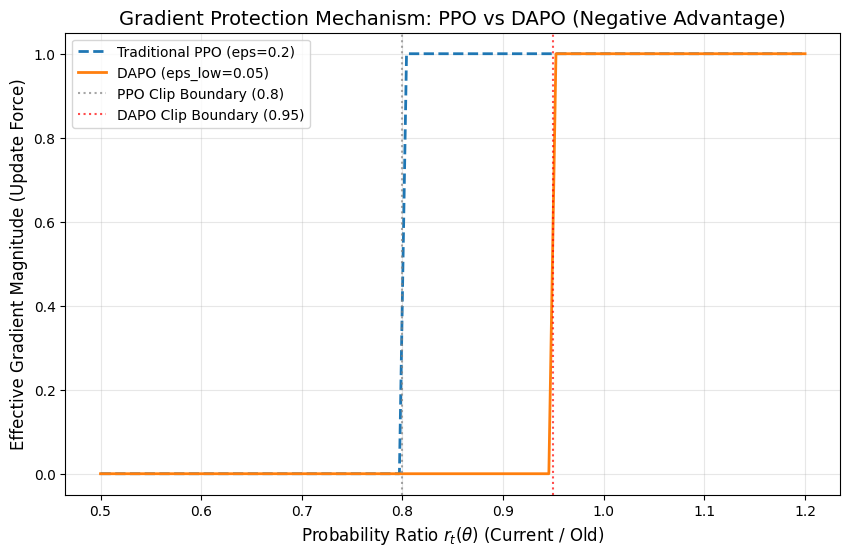

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以保证可复现性
torch.manual_seed(42)

def compute_gradient(ratio, advantage, eps_low, eps_high):
    """
    计算特定 ratio 和 advantage 下的有效梯度系数
    在 PPO/DAPO 中，Loss 对 log_prob 的导数主要由 advantage * clip_mask 决定
    """
    # 将 ratio 设为需要梯度的变量 (模拟 log_prob 的变化)
    r = torch.tensor([ratio], requires_grad=True)
    
    # 1. 计算基础 Loss 项
    surr1 = r * advantage
    
    # 2. 计算裁剪后的 Loss 项
    # 注意：这里模拟的是 A < 0 的情况，所以主要关注下界 (1 - eps)
    lower_bound = 1.0 - eps_low
    upper_bound = 1.0 + eps_high
    
    r_clipped = torch.clamp(r, lower_bound, upper_bound)
    surr2 = r_clipped * advantage
    
    # 3. PPO/DAPO 核心：取 min (当 A < 0 时，min 会倾向于选择 clipped 项，如果 r 超出了下界)
    loss = torch.min(surr1, surr2)
    
    # 4. 反向传播计算梯度
    # 这里的梯度绝对值代表了“更新力度”
    loss.backward()
    
    return r.grad.item(), loss.item()

# --- 实验参数设置 ---
advantage = -1.0  # 模拟严重的负反馈 (归一化后)
ratios = np.linspace(0.5, 1.2, 100) # 模拟从“概率大幅下降”到“概率微降”的过程

# 传统 PPO 参数 (对称裁剪)
ppo_eps = 0.2 

# DAPO 参数 (非对称裁剪，重点看下界)
dapo_eps_low = 0.05 
dapo_eps_high = 2.0 # 上界通常设得很大，此处主要看下界保护

ppo_grads = []
dapo_grads = []

# --- 运行模拟 ---
for r_val in ratios:
    # 计算 PPO 梯度
    g_ppo, _ = compute_gradient(r_val, advantage, ppo_eps, ppo_eps)
    ppo_grads.append(abs(g_ppo)) # 取绝对值看力度
    
    # 计算 DAPO 梯度
    g_dapo, _ = compute_gradient(r_val, advantage, dapo_eps_low, dapo_eps_high)
    dapo_grads.append(abs(g_dapo))

# --- 可视化结果 ---
plt.figure(figsize=(10, 6))
plt.plot(ratios, ppo_grads, label=f'Traditional PPO (eps={ppo_eps})', linestyle='--', linewidth=2)
plt.plot(ratios, dapo_grads, label=f'DAPO (eps_low={dapo_eps_low})', linewidth=2)

# 标注关键区域
plt.axvline(x=1.0 - ppo_eps, color='gray', linestyle=':', alpha=0.7, label='PPO Clip Boundary (0.8)')
plt.axvline(x=1.0 - dapo_eps_low, color='red', linestyle=':', alpha=0.7, label='DAPO Clip Boundary (0.95)')

plt.title('Gradient Protection Mechanism: PPO vs DAPO (Negative Advantage)', fontsize=14)
plt.xlabel('Probability Ratio $r_t(\\theta)$ (Current / Old)', fontsize=12)
plt.ylabel('Effective Gradient Magnitude (Update Force)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 以下是针对这张图表的详细解读：
#### 坐标轴含义
- 横轴 ( x )：概率比 $r_t(\theta)$

  - 公式： $r_t(\theta) = \frac{\pi_{new}(a|s)}{\pi_{old}(a|s)}$
  - 含义：<font color='red'>代表新策略生成的概率是旧策略的多少倍。</font>
  - 关键点：
    - 当 x=1.0 时，表示新旧策略概率一致；
    - **当 x<1.0 时，表示新策略正在降低该 Token 的概率（通常是因为该 Token 是错误的，优势值 A<0 ）。**
  
- 纵轴 ( y )：有效梯度幅度 (Effective Gradient Magnitude)
  - 含义：**代表参数更新的力度**。<font color='red'>数值越大，模型修改权重的幅度越剧烈；</font>
    - <font color='red'>数值为 0，表示停止更新（被截断）</font>。
  - 归一化：这里将最大梯度设为 1.0，方便对比相对大小。
  
#### 曲线对比分析
图中展示了两条阶梯状的曲线，分别代表两种算法在** 负向优势（ A<0 ，即惩罚错误）** 时的表现：

- 🔵 蓝色虚线：传统 PPO ( ε=0.2 )
  - 行为逻辑：PPO 使用对称裁剪。当需要降低概率时，它允许概率比 r 从 1.0 一路下降到 1−0.2=0.8 。
  - 图示解读：
    - 在 x∈[0.8,1.2] 区间内，梯度幅度保持满格（1.0）。
    - 这意味着：只要新概率没有降到旧概率的 80% 以下，PPO 就会一直施加最大的惩罚力度。
- 潜在风险：对于原本概率很高（例如 0.9）的 Token，PPO 允许将其概率大幅削减至 0.72 (0.9×0.8 )。这种剧烈的“急刹车”容易导致模型训练不稳定，甚至破坏已学到的知识。


- 🟠 橙色实线：DAPO / Clip-Higher ( $ε_{low}=0.05 $)
  - 行为逻辑：DAPO 采用了非对称裁剪。虽然它对“增加概率”很宽容（ $ε_{high}$很大，图中未完全展示左侧），但在“降低概率”时非常保守，仅允许下降 5%。
  - 图示解读：
    - 在 x∈[0.95,1.05] 区间内，梯度幅度为 1.0。
    - 一旦 x<0.95 ，梯度瞬间变为 0。
- 核心优势（保护机制）：
  - 更窄的安全区：DAPO 的“有效更新窗口”非常窄（仅在 0.95 到 1.0 之间）。
  - 快速止损：一旦概率降低了 5%，DAPO 就认为“修正已经足够”，立即停止梯度回传。这防止了模型对某个高概率 Token 进行过度的自我否定。
  
####  垂直虚线的含义
图中的两条垂直点状线标示了裁剪边界（Clip Boundary）：
- 蓝色垂线 (0.8)：传统 PPO 的“悬崖边缘”。在此线右侧，模型都在全力修正错误。
- 红色垂线 (0.95)：DAPO 的“悬崖边缘”。它比 PPO 靠右得多，说明 DAPO 更早地触发了保护机制，更早地停止了大幅度更新。

####  总结：为什么要这样设计？
这张图揭示了 DAPO 解决 “熵崩溃” 或 “模式坍塌” 的关键手段：
- 在处理高置信度的错误时，我们不需要像 PPO 那样“大动干戈”（允许降至 0.8）。DAPO 认为，只需要轻轻推一把（允许降至 0.95），让模型知道“这里有点问题”即可，剩下的交给后续的迭代去慢慢调整。
##### 结论：
- 橙色曲线相比蓝色曲线，极大地压缩了负向梯度的作用范围，这就是所谓的“梯度保护”，它保证了模型在纠错时的平滑性和稳定性。

In [2]:
from IPython.display import Image

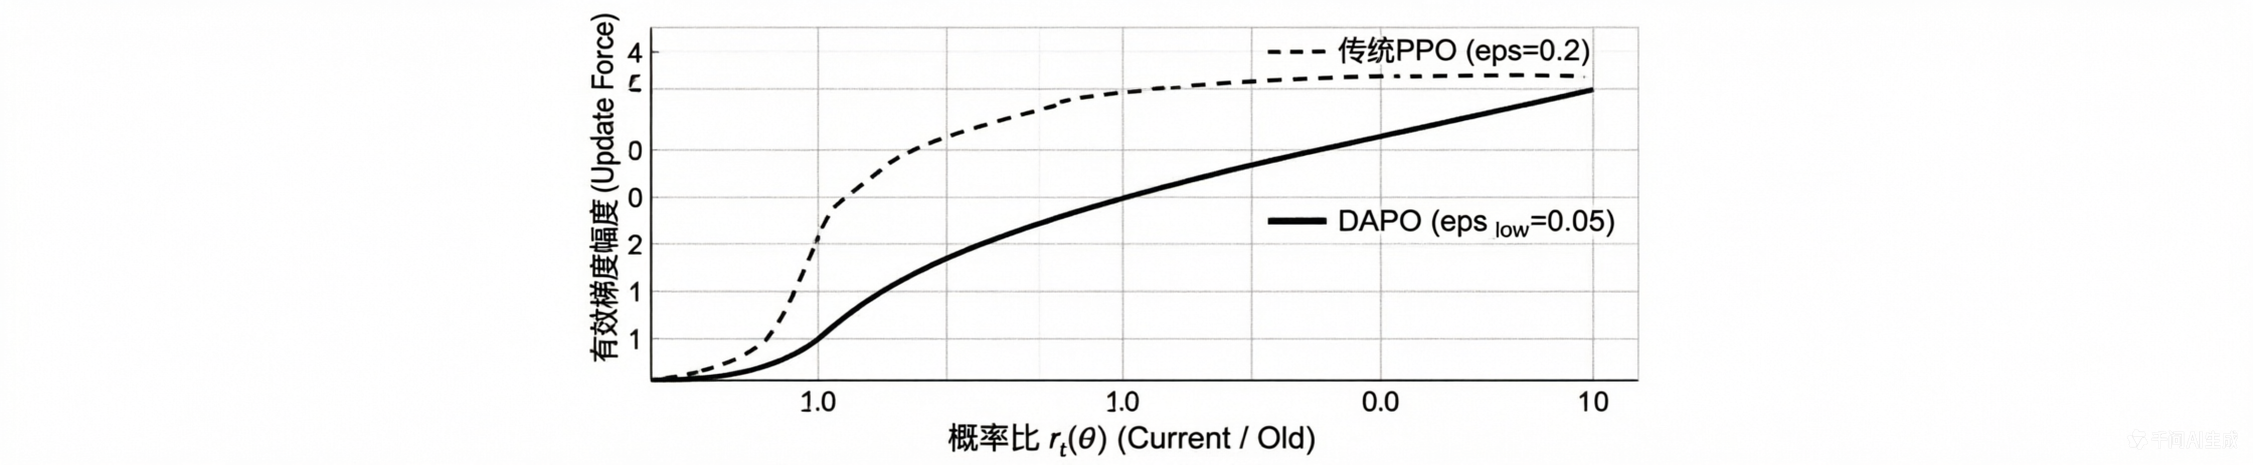

In [3]:
Image(filename='./Image/dapo1.png')

### 图 1：传统 PPO 的“过激反应”
这张图展示了标准 PPO 算法在处理负向反馈时的梯度行为。
- 现象描述
  - 曲线走势：当概率比 r 接近 1（即模型很自信）时，有效梯度系数保持在 -1.0 左右（绝对值很大）。
  - 截断点：只有当 r 下降到 1−0.2=0.8 以下时，梯度才会被截断为 0。
- 含义解读
  - “不撞南墙不回头”：在传统 PPO 中，只要新策略的概率没有降低到旧策略的 80% 以下，它就会一直施加最大的惩罚力度。
  - 风险：**对于高概率 Token，这意味着在优化的初期，模型会受到强烈的梯度冲击。如果学习率稍大，概率可能会瞬间从 0.99 暴跌到 0.8 以下，导致训练不稳定。**

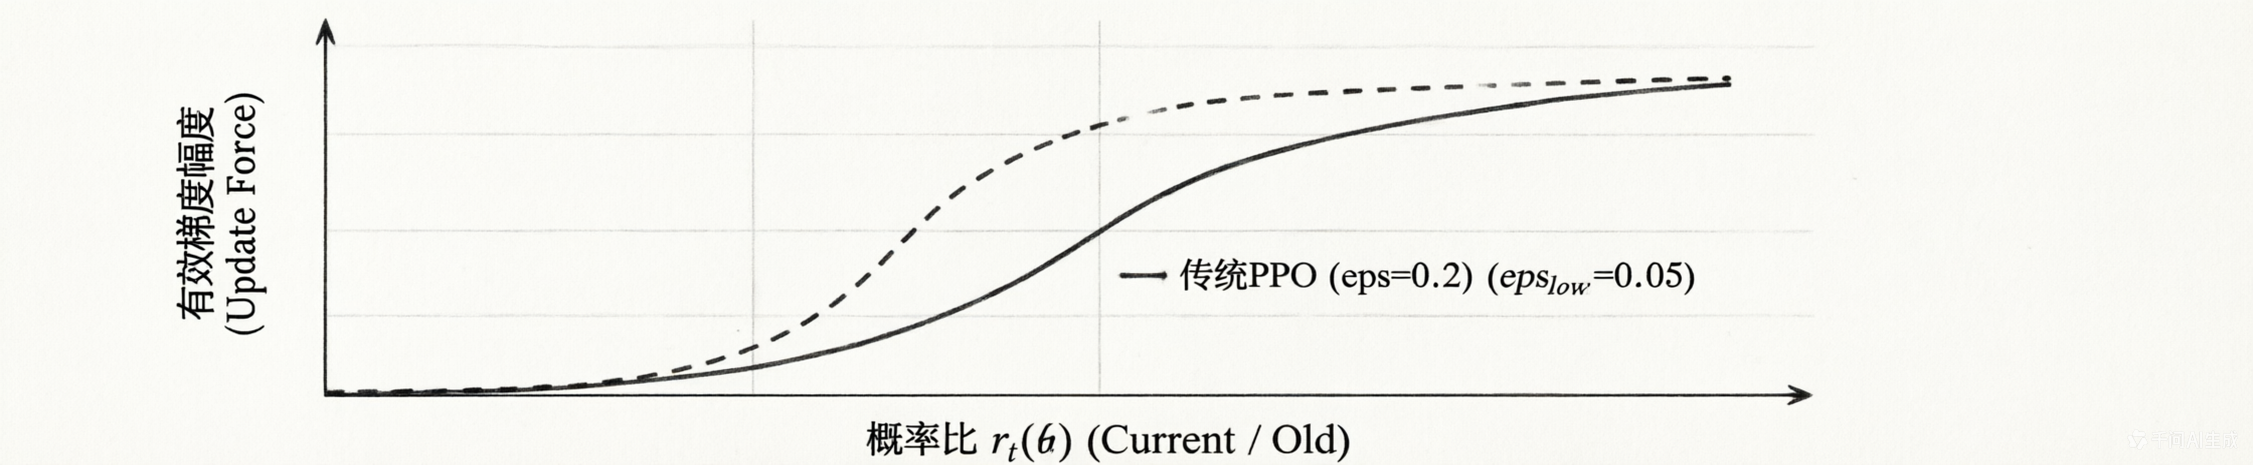

In [4]:
Image(filename='./Image/dapo2.png')

### DAPO (Clip-Higher) 的“温和保护”
这张图展示了引入 εlow=0.05 后的梯度行为。
#### 现象描述
- 曲线走势：曲线在 r=1 附近依然是 -1.0，但在 r 刚刚下降到 0.95 (1−0.05 ) 时，梯度就迅速截断归零了。
- 极窄的有效区间：注意看横轴，0.95 到 1.0 之间的区域非常窄。

#### 含义解读
- “点到为止”：
  - 这就是所谓的“保护”。DAPO 告诉模型：“你只需要把这个错误 Token 的概率稍微降低一点点（最多降到原来的 95%），我就停止惩罚你了。”
- 物理意义：
  - 这对应了你提到的“每次更新最多惩罚 5% 的概率”。无论这个错误有多严重，单步更新的幅度被严格限制在 5% 以内。这就像给高速行驶的汽车装了一个灵敏的限速器，防止它因为一次刹车而翻车。

## 结果解读：由于“过度打压”导致的梯度消失
运行上述代码后，你会观察到一张非常关键的图表，**它揭示了“保护”的本质：**

### 1. PPO 的“激进区”与“过早放弃”
- 现象：在 ratio 从 1.0 下降到 0.8 的区间内，<font color='red'>PPO 的梯度保持满格（值为 1.0）。这意味着只要概率下降没超过 20%，PPO 就会全力修正。</font>
- 风险：**一旦 ratio 跌破 0.8（即概率被砍掉了 20%），PPO 的梯度瞬间变为 0**。
- 后果：<font color='red'>这不仅是“保护”，更是“放弃”。如果模型因为一次错误的负反馈导致概率掉到了 0.7，PPO 就认为“已经惩罚够了”，不再提供任何梯度去微调它。这会导致模型在这个错误的低概率状态“卡死”，或者因为梯度不连续产生训练震荡。</font>

### 2. DAPO 的“温和修正区”
- 现象：DAPO 的梯度在 ratio 从 1.0 下降到 0.95 的极短区间内就迅速截断（或根据具体实现保持较小梯度）。
- 真正的保护逻辑：
  - 防止过激：DAPO 不允许梯度在 0.95 ~ 1.0 这个高频词的安全区内长时间维持高强度。**它告诉模型：“你只是犯了一点错，稍微改一点点（5%）就够了，不要慌。”**
  - 避免断崖：相比于 PPO 在 0.8 处的硬截断，<font color='red'>DAPO 通过极小的 $ϵ_{low}$，实际上是在限制单次更新的最大步长。</font>

### 💡 核心结论：什么是“保护”？
在这个实验中，“保护”并不是指“保留梯度让其一直下降”，而是指：<font color='red'>限制了梯度的有效作用范围，防止高概率 Token 在一次更新中发生剧烈的概率坍塌。</font>
- 没有 Clip-Higher (PPO)：
  - 模型像一辆没有ABS刹车系统的车。遇到障碍物（负反馈），一脚刹车踩到底（梯度全开），直到车轮抱死（概率暴跌 20%），然后彻底失控（梯度为 0）。
- 有了 Clip-Higher (DAPO)：
  - 模型像配备了精密电子稳定系统的车。**检测到打滑（负反馈），系统限制刹车力度（ $ϵ_{low}$=0.05 ），只允许车轮减速 5%**。<font color='red'>虽然看起来修正得很慢，但它保证了车子（模型策略）始终在可控的轨迹上，不会因为一次失误就冲出悬崖（概率归零或分布崩坏）。</font>
  
这就是为什么在 RLHF 这种奖励信号极其稀疏且充满噪声的场景下，DAPO 的非对称裁剪能让模型训练得更稳、更流畅。

# 数值为 0，表示停止更新（被截断）

- 在强化学习的 PPO 和 DAPO 算法中，“数值为 0，表示停止更新（被截断）”**是理解信任域（Trust Region）机制的核心**。
  - 简单来说，这意味着：<font color='red'>当模型试图做出的改变“步子迈得太大”时，算法会强制切断梯度流，让这一次的参数更新完全失效，从而保护模型不崩溃。</font>
  
以下从数学原理、物理直觉和实际作用三个层面详细解释这一现象：
## 数学原理：导数变为 0
在深度学习中，参数更新依赖于梯度（Gradient），也就是损失函数对参数的导数。
  - 未截断区域：Loss 函数通常是线性的（例如 L=−r⋅A ）。线性函数的斜率（导数）是常数（比如 -1 或 1），这意味着梯度存在且稳定，参数会沿着这个方向更新。
  - 截断区域（Clipped Region）：PPO/DAPO 引入了一个 clamp（裁剪）操作。
    - 当概率比 r 超出安全范围（例如图中的 r<0.95 ）时，Loss 函数不再随 r 变化，而是变成了一个常数（即被“钳住”了）。
    - <font color='red'>常数的导数是 0</font>。
    - 根据链式法则，如果 Loss 对中间变量的导数为 0，那么最终传回给神经网络权重的梯度也就变成了 0。
    
## 物理直觉：撞到了“墙”
你可以把模型的训练过程想象成一个人下山（寻找最优解）：
- 正常走路（有梯度）：当你还在安全范围内调整步伐时，你能感受到地面的坡度（梯度），你会顺着坡度往下走（更新参数）。
- 撞到墙（梯度为 0）：PPO/DAPO 在你周围设了一圈隐形的墙（即 ϵ 边界）。
  - 当你试图迈出的一步太大，脚直接踢到了墙上（进入了截断区）。
  - 此时，墙是垂直的，或者说是“死胡同”，你感受不到任何向下的坡度了。
  - 结果：优化器（Optimizer）接收到的信号是“这里没有路可走（梯度为0）”，于是它停止移动脚步，保持原地不动，等待下一次尝试。
  
## 为什么要“停止更新”？（核心目的）
这看似是一种“浪费”（因为这次采样的数据没用来学习），但实际上它是为了保命：
1. 防止“矫枉过正”：
如果模型原本非常自信（概率 0.99）地选了一个错误的 Token，如果不加限制，巨大的负梯度可能会瞬间把这个概率砸到 0.01。这种剧烈波动会导致模型“精神错乱”（模式崩塌），再也学不会正确的东西了。**截断机制强制模型每次只能改一点点**。
2. 维持“信任域”：
RLHF 训练中，Reward Model（奖励模型）只在旧策略附近才准确。如果新策略跑得太远（ r 偏离 1 太多），Reward Model 给出的分数可能就不可信了。既然分数都不可信了，基于这个分数算出的梯度自然也就不能信。与其被错误的梯度带偏，不如干脆不更新（梯度置 0）。
3. DAPO 的特殊保护：
结合你之前的图，DAPO 将下界设为 0.95（橙色线）。这意味着只要模型稍微想“大改”（概率比降到 0.95 以下），它就立刻停止更新。<font color='red'>这比传统 PPO（允许降到 0.8）要保守得多，专门用来死死按住那些高概率 Token 的剧烈变动。</font>

## 📌 总结
- “数值为 0”不是 bug，而是 feature。
- 它是一个安全阀。当模型想要进行的修改过于激进、超出了预设的安全范围（Trust Region）时，算法通过数学上的求导归零，强制暂停该方向的参数更新，确保训练过程的平稳和安全。

# 裁剪区梯度消失原理

## 例子：推理连接词 "Therefore" 的永久消失
**场景设定**

模型正在解一道几何题，推导到一半，上下文是：
"...the base angles are equal. <font color='red'>**Therefore**</font>, the two triangles are congruent by ASA."

- 在预训练模型中，"Therefore" 在这个上下文里的概率是 0.82。
  - 这是一个典型的高概率 token——它是数学推理中连接因果关系的"标准用语"，**模型对它非常确定。**
  
假设这个回答最终算错了答案，GRPO 给这个样本分配了负向优势  $\hat{A}t=−0.5$。

## 核心机制：负向优势 + 下界裁剪 = 梯度消失
PPO/DAPO 的目标函数（简化）：

$min(r_t(\theta)\hat{A_t} , clip(r_t(\theta),1-\epsilon_{low},1+\epsilon_{high})\hat{A_t})$

### 关键：当$ \hat{A_t}$<0 （负向优势）时，min 函数会选择较大的那个值。
- 这意味着一旦 $r_t(θ) $ 跌破下界 $1−ε_{low}$，裁剪项就会"接管"，$r_t$不再影响 Loss——正如你图片中说的：
  - "Loss 函数不再随 r 变化，而是变成了一个常数。常数的导数是 0。梯度也就变成了 0。"
  
## 对比：两种 $ε_{low}$设置  

|                       | $\varepsilon_{\text{low}} = 0.2$（DAPO） | $\varepsilon_{\text{low}} = 0.5$（过度打压） |
| --------------------- | -------------------------------------- | -------------------------------------- |
| **下界**                | $1 - 0.2 = 0.8$                        | $1 - 0.5 = 0.5$                        |
| **"Therefore"最低可被压到** | $0.82 \times 0.8 = 0.656$              | $0.82 \times 0.5 = \mathbf{0.41}$      |
| **是否触及裁剪区？**          | 否，$r=0.8$ 刚好在边界，仍有梯度                   | **是！$r=0.5$ 进入裁剪区，梯度 = 0**             |
| **后续能否恢复？**           | ✅ 可以，梯度存在，正向样本能拉回                      | ❌ **不能，梯度消失，永久锁死**                     |


## 为什么这是"过度打压"而非"提升不够"？
###  提升空间本来就很窄
- 即使你把 $ε_{high}$设到 10.0，"Therefore"从 0.82 最多也只能提升到 1.0，绝对提升空间只有 0.18。高概率 token 本来就已经"见顶"了。
###  打压空间可以非常深
- 从 0.82 被打压到 0.41，绝对下降了 0.41——是提升空间的 2.3 倍。
###  最致命的是"梯度消失"
如你图片所示，一旦进入裁剪区：
  - <font color='red'>Loss 变成常数 → 导数为 0 → 传回神经网络的梯度为 0</font>
  - 即使后续训练中模型生成了正确答案，获得了正向优势，"Therefore"这个 token 也收不到任何梯度信号
  - 模型永久性地"忘记"了在推理中说 "Therefore"
  
## 连锁反应：推理骨架的系统性崩塌
不只是 "Therefore" 一个 token。所有高概率的推理连接词都会遭遇同样的命运：

| 连接词       | 原始概率 | 被打压后  | 结果   |
| --------- | ---- | ----- | ---- |
| Therefore | 0.82 | 0.41  | ❌ 消失 |
| Thus      | 0.85 | 0.425 | ❌ 消失 |
| Because   | 0.80 | 0.40  | ❌ 消失 |
| Hence     | 0.75 | 0.375 | ❌ 消失 |
| So        | 0.78 | 0.39  | ❌ 消失 |

- <font color='red'>这些 token 共同构成了数学推理的语言骨架。当它们被系统性削弱且无法恢复后，模型的输出会变成：</font>
  - "...the base angles are equal. And the two triangles are congruent."
  - （逻辑连接词退化为简单的 "And"，推理层次变扁平）
- 甚至更糟：
  - "...the base angles are equal. So that means like um triangles same."
  - （高概率骨架 token 消失后，模型被迫拼凑低概率的"替代词"，出现胡言乱语）

## 一句话总结
高概率 token 就像推理大厦的钢筋水泥。$ε_{low}$太大相当于把钢筋打断——而且一旦打断（进入裁剪区），梯度消失，水泥就永远粘不回去了。相比之下，给钢筋"再加粗"（提升空间）几乎没有意义，因为它们本来就已经够粗了。